In [0]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

2025-11-02 07:55:35.253369: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-02 07:55:35.287223: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-02 07:55:35.588137: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-02 07:55:43.404046: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TensorFlow version: 2.16.1


In [0]:
import warnings
warnings.filterwarnings('ignore')

In [0]:
import numpy as np
import matplotlib.pyplot as plt
import math


Colectia de date:MNIST.

Colectie de imagini cu cifre scrise de mana care se foloseste pentru antrenarea modelelor de ML de recunoastere a scrisului de mana.

Multimea de training contine 60.000 imagini de dimensiune 28x28 grayscale ale celor 10 cifre. Multimea de testare contine 10.000 imagini.
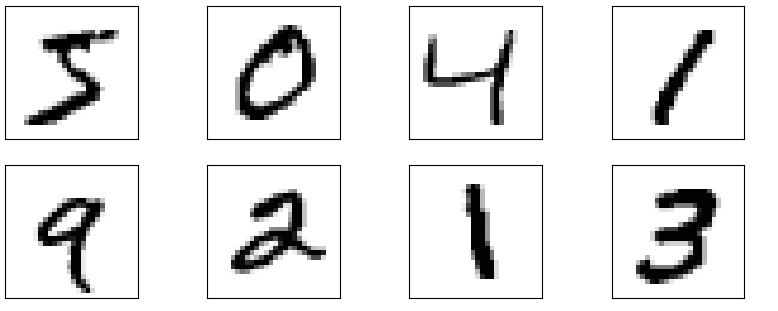

In [0]:
#incarcam baza de date

mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
#x_train, x_test = x_train / 255.0, x_test / 255.0

Colectiile rezultate sunt np arrays.

In [0]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [0]:
x_train.shape

(60000, 28, 28)

In [0]:
x_test.shape

(10000, 28, 28)

In [0]:
y_train.shape

(60000,)

In [0]:
y_test.shape

(10000,)

In [0]:
x_test.size

7840000

In [0]:
 x_test.max()

255

In [0]:
x_test.min()

0

In [0]:
x_train[0]/255

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [0]:
x_train, x_test = x_train / 255.0, x_test / 255.0

In [0]:
x_test[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [0]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [0]:
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [0]:
print(y_test.min(), y_test.max())

0 9


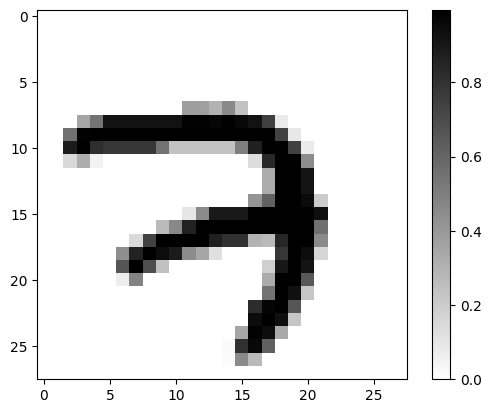

In [0]:
plt.figure()
plt.imshow(x_train[5000], cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

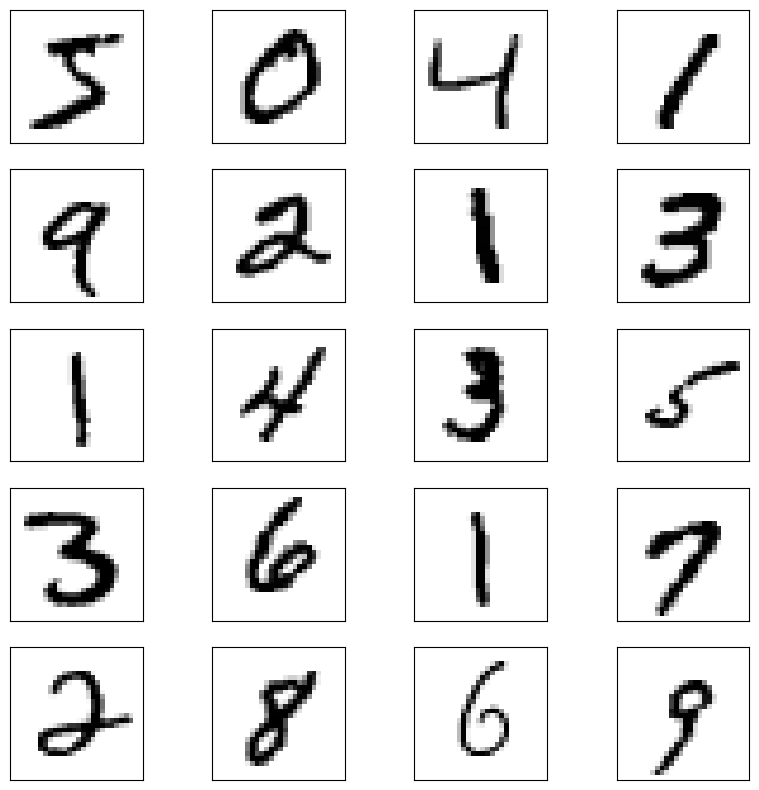

In [0]:
plt.figure(figsize=(10,10))
for i in range(20):
    plt.subplot(5,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i], cmap=plt.cm.binary)
plt.show()

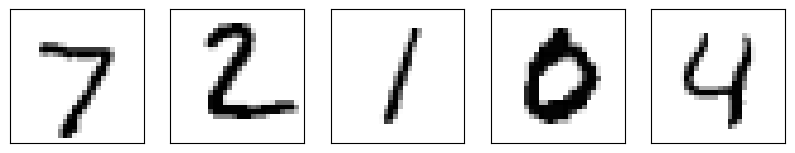

In [0]:
plt.figure(figsize=(10,10))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[i], cmap=plt.cm.binary)
plt.show()

Construirea modelului.

Stabilirea straturilor.

In [0]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(10)
])

In [0]:
model.summary()
# 784 = 28*28
# 100480 = 128*785 (atatea ponderi sunt la acest nivel)
# 1290 = 10 *129 (atatea ponderi sunt la acest nivel)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

784 = 28*28

100480 = 128*785 (atatea ponderi sunt la acest nivel)

1290 = 10 *129 (atatea ponderi sunt la acest nivel)

Modelul trebuie optimizat. Se defineste functia cost.

SparseCategoricalCrossentropy:

In [0]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [0]:
model.compile(#optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

In [0]:
model.fit(x_train, y_train, epochs=5)

2025-11-02 07:56:14.937069: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


Epoch 1/5
1002/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8592 - loss: 0.5080

*** WARNING: max output size exceeded, skipping output. ***

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9839 - loss: 0.0532


Înainte de a începe antrenarea retelei, configuram și compilam modelul folosind funcția model.compile din Keras.

optimizarea ratei de invatare
functia cost
metrica folosita pentru evaluarea modelului

Modelul trebuie optimizat. Se defineste functia cost.

SparseCategoricalCrossentropy:

In [0]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

Compilarea modelului.

In [0]:
model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

Antrenarea modelului. Alegem nr de iteratii (epochs).


https://keras.io/api/models/model_training_apis/

In [0]:
model.fit(x_train, y_train, epochs=5)

2025-11-02 08:00:53.092858: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


Epoch 1/5
 

*** WARNING: max output size exceeded, skipping output. ***

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.9944 - loss: 0.0189


Evaluarea modelului.

verbose: 'auto', 0, 1, or 2. Verbosity mode. 0 = silent, 1 = progress bar, 2 = one line per epoch.

In [0]:
model.evaluate(x_test,  y_test, verbose=1)

2025-11-02 08:02:35.790880: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9709 - loss: 0.1106


[0.09485126286745071, 0.9739999771118164]

Daca se doreste ca modelul sa returneze o probabilitatea atunci putem adauga functia softmax la sfarsit.

In [0]:
predictions = model(x_train[:1]).numpy()
predictions
#3.9944246e-01 = 3.9944246*10^(-1)= 0.39944246

array([[-45.556984  , -35.787304  , -33.48971   ,  -9.621764  ,
        -70.83404   ,   0.21041487, -47.816162  , -31.069235  ,
        -35.148285  , -27.266344  ]], dtype=float32)

In [0]:
probability_model = tf.keras.Sequential([model,
                                         tf.keras.layers.Softmax()])

Obtinerea predictiilor.

In [0]:
predictions = probability_model.predict(x_test)

2025-11-02 08:02:38.035305: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [0]:
predictions.shape

(10000, 10)

Fiecare predictie este un vector de 10 numere reale. Acestea reprezinta probabilitatea cu care imaginea corespunde unuia din cele 10 valori de iesire. Valoarea cu probabilitatea cea mai mare va corespunde valorii clasei estimate.


In [0]:
predictions

array([[2.9896057e-12, 2.8946995e-14, 5.0503131e-09, ..., 9.9999946e-01,
        2.2266730e-10, 3.1390737e-08],
       [6.3061839e-10, 6.1270713e-09, 9.9999636e-01, ..., 7.7031426e-18,
        3.0166564e-11, 1.2262358e-15],
       [7.3711249e-08, 9.9813688e-01, 6.9509937e-05, ..., 1.1670130e-03,
        5.6318764e-04, 3.9511498e-08],
       ...,
       [1.9612343e-18, 1.2225355e-15, 2.4959840e-16, ..., 5.2168143e-06,
        6.6947287e-08, 1.0633374e-05],
       [3.5800671e-09, 6.5986538e-10, 3.1292492e-13, ..., 2.4220457e-11,
        8.2088927e-06, 5.5525463e-13],
       [7.6211021e-13, 9.2825861e-18, 6.6815187e-15, ..., 1.2198326e-18,
        3.7540466e-14, 5.0594576e-12]], dtype=float32)

In [0]:
predictions[0] # predictia pentru prima imagine din multimea de testare

array([2.9896057e-12, 2.8946995e-14, 5.0503131e-09, 4.7066777e-07,
       3.4440346e-16, 5.4576444e-11, 2.0735642e-18, 9.9999946e-01,
       2.2266730e-10, 3.1390737e-08], dtype=float32)

In [0]:
np.argmax(predictions[0]) # valoarea care este considerata ca si clasa estimata

7

In [0]:
y_test[0] # identica cu valoarea clasei corespunzatoare imaginii (prima imag este 7)

7

In [0]:
t = np.arange(len(y_test))
for i in range(len(y_test)):
  t[i] = math.fabs(np.argmax(predictions[i]) - y_test[i])
print(np.mean(t))
print(np.argmax(t))

0.1035
3251


Verificarea predictiilor

Definim functii care sa reprezinte grafic imaginile si predictiile corespunzatoare.

In [0]:
# functie pentru reprezentarea imaginii
def plot_image(i, predictions_array, true_label, img):
  true_label, img = true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel(" {:2.0f}% ()".format(100*np.max(predictions_array),
                               color=color))

In [0]:
# functie pentru reprezentarea predictiilor
def plot_value_array(i, predictions_array, true_label):
  true_label = true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

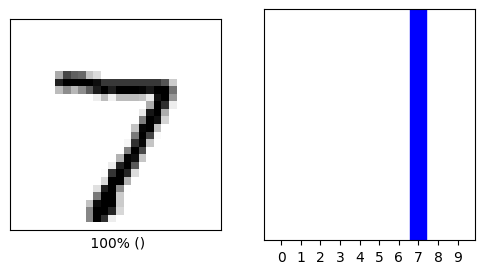

In [0]:
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], y_test, x_test)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  y_test)
plt.show()

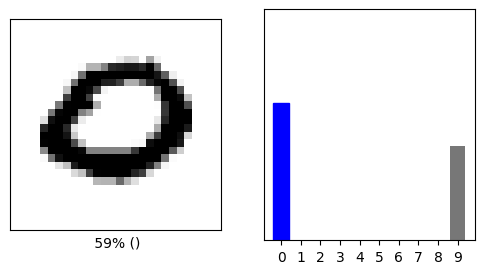

In [0]:
i = 1987 #126
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], y_test, x_test)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  y_test)
plt.show()

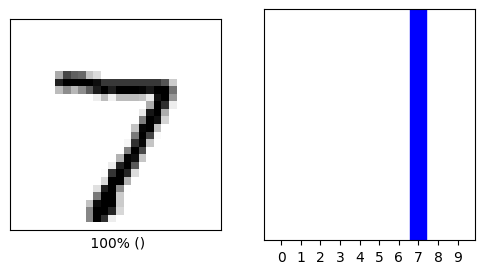

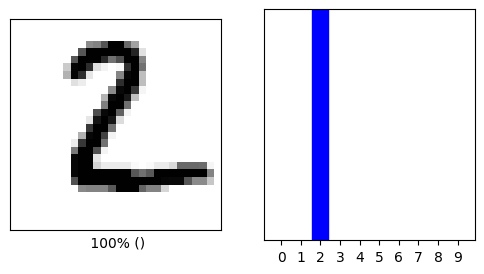

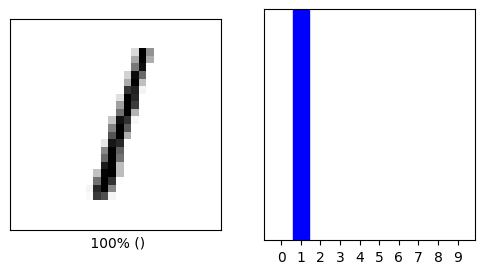

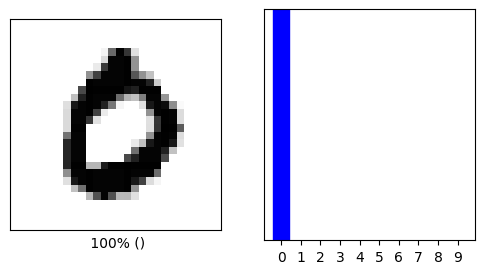

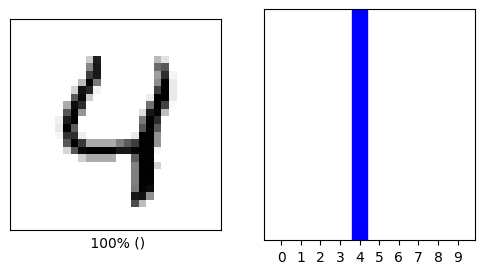

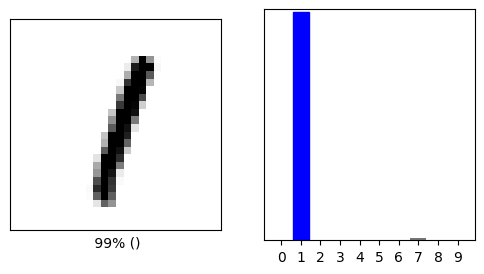

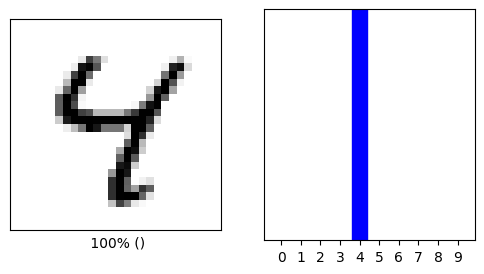

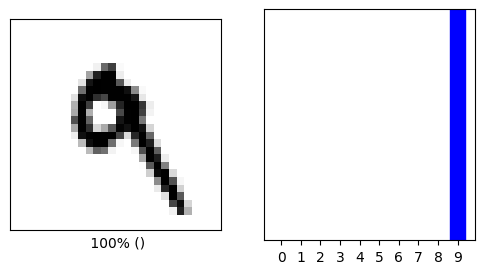

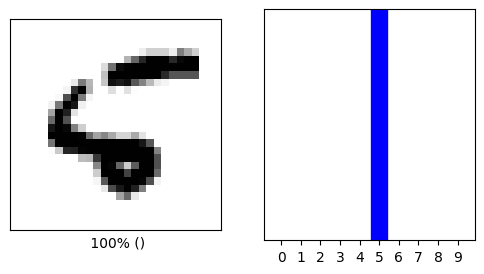

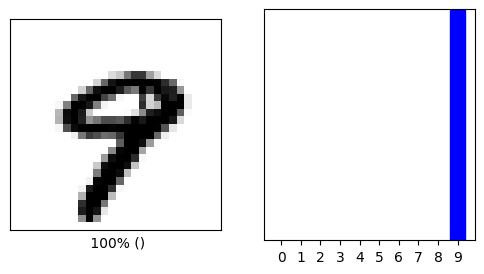

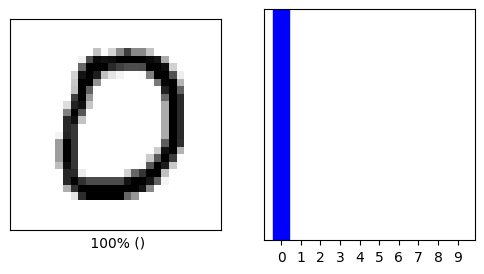

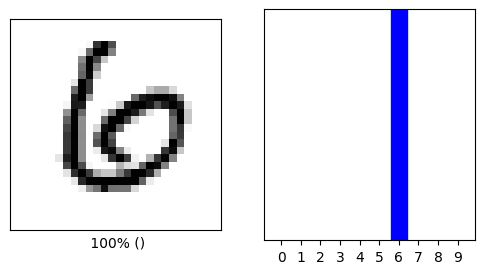

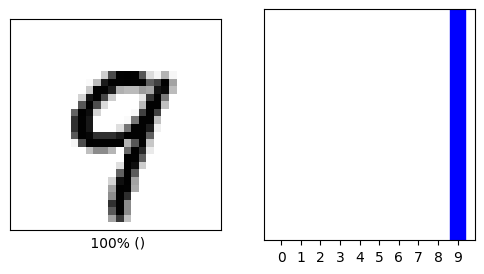

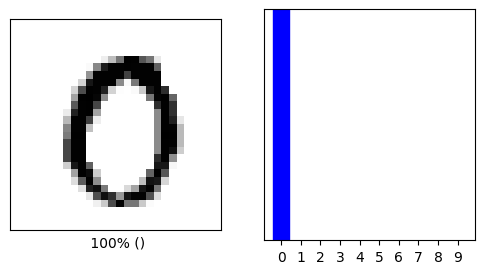

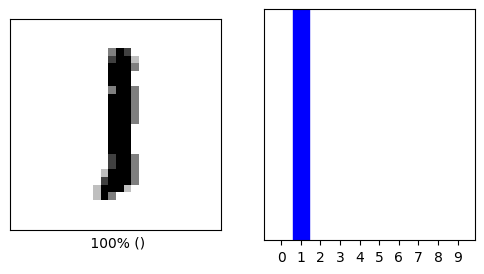

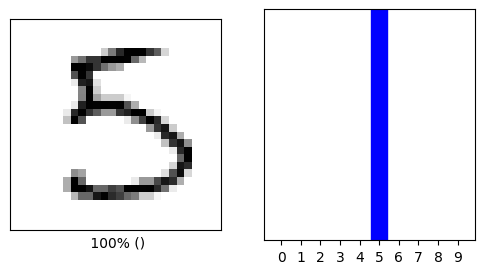

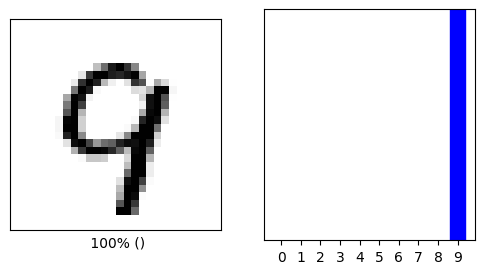

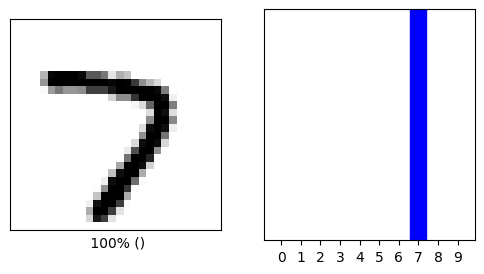

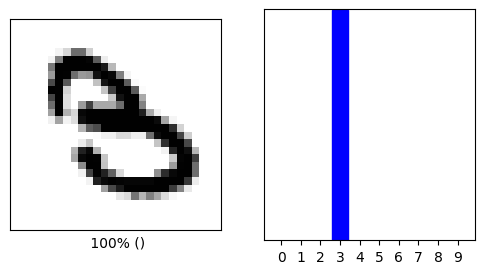

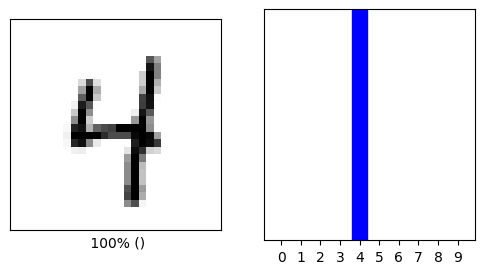

In [0]:
 j= 0
 for i in range(20):
  plt.figure(figsize=(6,3))
  plt.subplot(1, 2, 1)
  plot_image(i, predictions[i], y_test, x_test)
  plt.subplot(1, 2, 2)
  j +=2
  plot_value_array(i, predictions[i],  y_test)
  plt.show()

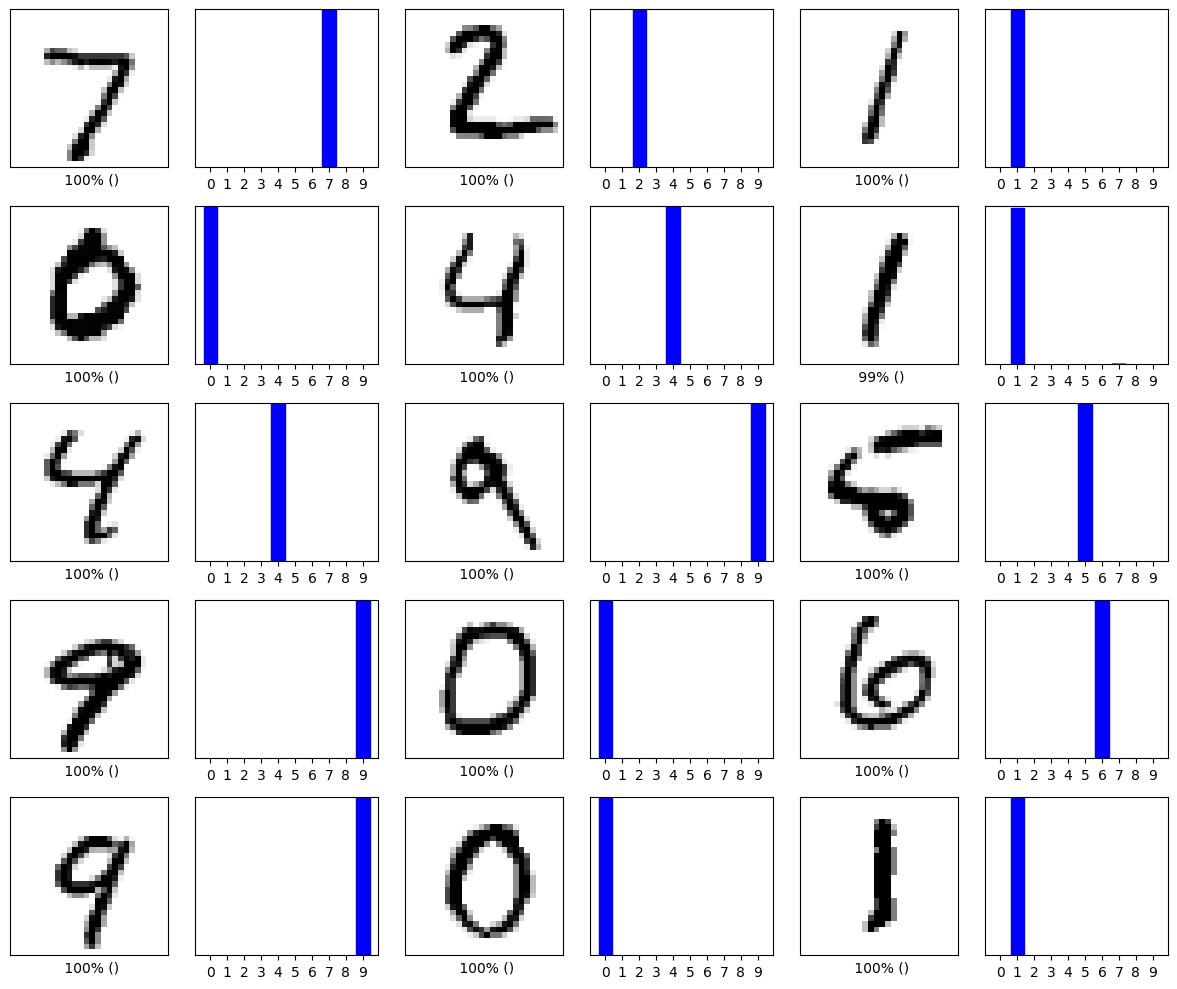

In [0]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions[i], y_test, x_test)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions[i], y_test)
plt.tight_layout()
plt.show()